# ============================================================
# 📚 Project - CATT: Character-based Arabic Tashkeel Transformer (LAB) 👨🏻‍💻📖
# ============================================================

# =========================
# 1️⃣ Required Libraries
# =========================

In [12]:
import torch
import torch.optim as optim
import re

from tashkeel_tokenizer import TashkeelTokenizer
from eo_pl import TashkeelModel

In [13]:
def remove_tashkeel(text):
    arabic_diacritics = re.compile(r'[ًٌٍَُِّْـ]')
    return re.sub(arabic_diacritics, '', text)

# =========================
# 2️⃣ Read Dataset
# =========================

In [20]:
data = []

with open("Arabic-Original.csv", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("|")
        
        if len(parts) < 3:
            continue

        tashkeel_text = parts[2]
        input_text = remove_tashkeel(tashkeel_text)

        data.append((input_text, tashkeel_text))

# للتجربة السريعة
data = data[:2000]

print("Sample:", data[0])

Sample: ('بسم الله الرحمٰن الرحيم', 'بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ')


# =========================
# 3️⃣ Load Pretrained Model From HuggingFace
# =========================

In [21]:
tokenizer = TashkeelTokenizer()

model = TashkeelModel(
    tokenizer,
    max_seq_len=1024,
    n_layers=6,
    learnable_pos_emb=False
)

model.load_state_dict(torch.load("models/best_eo_mlm_ns_epoch_193.pt", map_location="cpu"))

model.train()

TashkeelModel(
  (transformer): Transformer(
    (encoder): Encoder(
      (emb): TransformerEmbedding(
        (tok_emb): TokenEmbedding(41, 512, padding_idx=0)
        (pos_emb): SinusoidalPositionalEncoding()
        (drop_out): Dropout(p=0.1, inplace=False)
      )
      (layers): ModuleList(
        (0-5): 6 x EncoderLayer(
          (attention): MultiHeadAttention(
            (attention): ScaleDotProductAttention(
              (softmax): Softmax(dim=-1)
            )
            (w_q): Linear(in_features=512, out_features=512, bias=False)
            (w_k): Linear(in_features=512, out_features=512, bias=False)
            (w_v): Linear(in_features=512, out_features=512, bias=False)
            (w_concat): Linear(in_features=512, out_features=512, bias=False)
          )
          (norm1): LayerNorm()
          (dropout1): Dropout(p=0.1, inplace=False)
          (ffn): PositionwiseFeedForward(
            (linear1): Linear(in_features=512, out_features=2048, bias=True)
         

# =========================
# 4️⃣ Initialize Optimizer
# =========================

In [22]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# =========================
# 5️⃣ Token Encoding Test
# =========================

In [23]:
print(tokenizer.encode("السلام عليكم"))

(tensor([ 1, 10, 25, 31, 25, 10, 26,  3, 12, 25, 36, 24, 26,  2]), tensor([1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2]))


# =========================
# 6️⃣ Check Output Shapes
# =========================

In [24]:
print(outputs.shape)
print(targets.max())

torch.Size([1, 111, 18])
tensor(5)


# =========================
# 7️⃣ Extract Arabic Diacritics Labels
# =========================

In [25]:
import unicodedata

# mapping بسيط للحركات
harakat_map = {
    '\u064e': 1,  # َ
    '\u064f': 2,  # ُ
    '\u0650': 3,  # ِ
    '\u0652': 4,  # ْ
    '\u0651': 5,  # ّ
}

def extract_labels(text):
    labels = []
    for char in text:
        if unicodedata.category(char) == 'Mn':
            labels.append(harakat_map.get(char, 0))
        else:
            labels.append(0)
    return labels

# =========================
# 8️⃣ Train Transformer Model
# =========================

In [26]:
for epoch in range(50):
    total_loss = 0

    for input_text, target_text in data:
        inputs = tokenizer.encode(input_text)[0]
        inputs = inputs.unsqueeze(0)

        # 🔥 target = harakat labels
        targets = extract_labels(target_text)
        targets = torch.tensor(targets, dtype=torch.long).unsqueeze(0)

        outputs = model(inputs)

        min_len = min(outputs.size(1), targets.size(1))
        outputs = outputs[:, :min_len, :]
        targets = targets[:, :min_len]

        loss = torch.nn.functional.cross_entropy(
            outputs.reshape(-1, outputs.size(-1)),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 4388.290669441223
Epoch 2, Loss: 2513.7303627729416
Epoch 3, Loss: 2465.3168954253197
Epoch 4, Loss: 2407.353361427784
Epoch 5, Loss: 2320.225281238556
Epoch 6, Loss: 2250.800189971924
Epoch 7, Loss: 2201.002921015024
Epoch 8, Loss: 2156.5366021096706
Epoch 9, Loss: 2119.2820483893156
Epoch 10, Loss: 2082.545783892274
Epoch 11, Loss: 2046.7427011728287
Epoch 12, Loss: 2011.5450235530734
Epoch 13, Loss: 1974.6932019740343
Epoch 14, Loss: 1938.662515975535
Epoch 15, Loss: 1908.130353845656
Epoch 16, Loss: 1870.3897215537727
Epoch 17, Loss: 1838.115085253492
Epoch 18, Loss: 1809.141508223489
Epoch 19, Loss: 1772.4818954383954
Epoch 20, Loss: 1743.3808634849265
Epoch 21, Loss: 1709.622774893418
Epoch 22, Loss: 1675.8488230616786
Epoch 23, Loss: 1646.9910674756393
Epoch 24, Loss: 1615.789297804702
Epoch 25, Loss: 1582.7594794686884
Epoch 26, Loss: 1552.4953949656337
Epoch 27, Loss: 1524.9027000456117
Epoch 28, Loss: 1495.8727040728554
Epoch 29, Loss: 1469.691434394801
Epoch 3

# =========================
# 9️⃣ Save Best Model
# =========================

In [27]:
best_loss = float("inf")

if total_loss < best_loss:
    best_loss = total_loss
    torch.save(model.state_dict(), "best_model.pt")

# =========================
# 🔟 Calculate Accuracy
# =========================

In [28]:
def calculate_accuracy(model, data):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for input_text, target_text in data:
            inputs = tokenizer.encode(input_text)[0].unsqueeze(0)

            targets = extract_labels(target_text)
            targets = torch.tensor(targets).unsqueeze(0)

            outputs = model(inputs)

            min_len = min(outputs.size(1), targets.size(1))
            outputs = outputs[:, :min_len, :]
            targets = targets[:, :min_len]

            predictions = torch.argmax(outputs, dim=-1)

            correct += (predictions == targets).sum().item()
            total += targets.numel()

    accuracy = correct / total
    return accuracy

# =========================
# 1️⃣1️⃣ Generate Predictions
# =========================

In [33]:
acc = calculate_accuracy(model, data[:100])
print("Accuracy:", acc)

Accuracy: 0.8235092136889093


# =========================
# 1️⃣2️⃣ Build Confusion Matrix
# =========================

In [34]:
from sklearn.metrics import confusion_matrix
import numpy as np

def get_predictions(model, data):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for input_text, target_text in data[:200]:  
            inputs = tokenizer.encode(input_text)[0].unsqueeze(0)

            targets = extract_labels(target_text)
            targets = torch.tensor(targets).unsqueeze(0)

            outputs = model(inputs)

            min_len = min(outputs.size(1), targets.size(1))
            outputs = outputs[:, :min_len, :]
            targets = targets[:, :min_len]

            preds = torch.argmax(outputs, dim=-1)

            all_preds.extend(preds.view(-1).tolist())
            all_targets.extend(targets.view(-1).tolist())

    return all_targets, all_preds

# =========================
# 1️⃣3️⃣ Visualize Confusion Matrix
# =========================

In [35]:
targets, preds = get_predictions(model, data)

cm = confusion_matrix(targets, preds)

print(cm)

[[11705    89    68    27    25    10]
 [ 1817  1640    11     3     4     7]
 [  351     0   671     2     0     0]
 [  579     1     2   617     7     1]
 [  581     5     7     8   629     0]
 [  221     6     2     1     1   305]]


# =========================
# 1️⃣4️⃣ Heatmap Visualization
# =========================

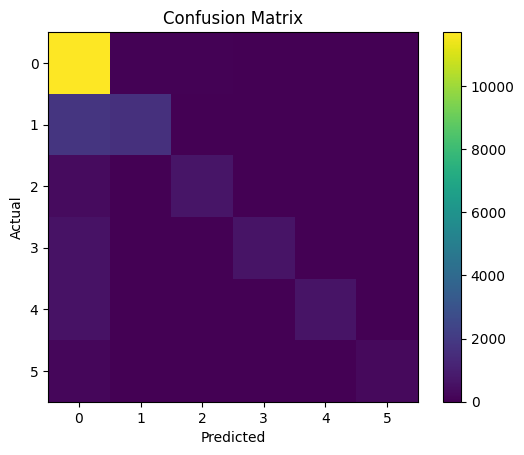

In [36]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

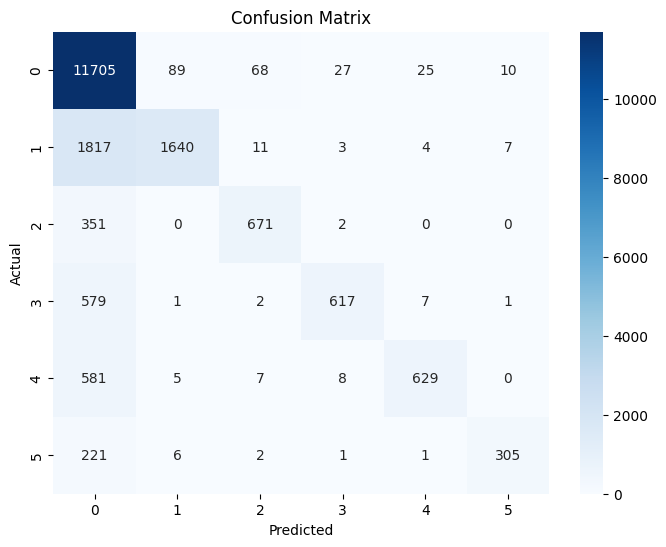

In [37]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()